In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ==================================
# Cell 1: Setup and Imports
# ==================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from transformers import CLIPProcessor
from tqdm import tqdm
from tqdm.notebook import tqdm
from google.colab import drive
import sys
import os

project_path = '/content/drive/My Drive/H-PeVL'
sys.path.append(f'{project_path}/src')

# Add your source code directory to the Python path
import importlib
# Remove the cached module if it exists
if 'dataloader' in sys.modules:
    del sys.modules['dataloader']

if 'model' in sys.modules:
    del sys.modules['model']

# Import your custom classes
from dataloader import FPHADataset
from model import HPeVLModel # <-- Import the new model



In [ ]:
import os

# 1. Define your source (Drive) and destination (Local)
# Make sure 'FPHA_dataset.zip' matches your actual zip filename on Drive
zip_path = '/content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB).zip'
local_extract_path = '/content/FPHA_Local'

# 2. Run the unzip logic
if not os.path.exists(local_extract_path):
    print("🚀 Copying zip from Drive to local runtime... (This speeds up training!)")
    # Copy to local disk first for faster/safer unzipping
    !cp "{zip_path}" /content/temp_dataset.zip

    print("📂 Unzipping dataset...")
    # Unzip quietly (-q) into the destination folder
    !unzip -q /content/temp_dataset.zip -d "{local_extract_path}"

    # Clean up to save disk space
    !rm /content/temp_dataset.zip
    print("✅ Unzipping complete! Data is ready in local runtime.")
else:
    print("✅ Dataset already found locally. Skipping unzip.")

🚀 Copying zip from Drive to local runtime... (This speeds up training!)
📂 Unzipping dataset...
✅ Unzipping complete! Data is ready in local runtime.


In [ ]:
import os
import glob

# 1. Set the path to where the Video_files are located
# This should match where you extracted the main zip
video_files_root = '/content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Video_files'

print(f"📂 Looking for zipped subjects in: {video_files_root}")

# 2. Find all Subject_*.zip files
zip_files = glob.glob(os.path.join(video_files_root, "Subject_*.zip"))

if len(zip_files) > 0:
    print(f"Found {len(zip_files)} nested zip files. Extracting now...")

    for zip_file in zip_files:
        print(f"   - Unzipping {os.path.basename(zip_file)}...")
        # Unzip into the same directory
        !unzip -q "{zip_file}" -d "{video_files_root}"

        # Delete the zip file to save disk space (Critical in Colab!)
        os.remove(zip_file)

    print("✅ All subjects extracted and zip files cleaned up!")
else:
    print("No zip files found. They might already be extracted.")

# 3. Verify the structure
print("\nVerifying extraction...")
subject_folders = glob.glob(os.path.join(video_files_root, "Subject_*"))
print(f"Found {len(subject_folders)} subject folders: {[os.path.basename(f) for f in subject_folders]}")

📂 Looking for zipped subjects in: /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Video_files
Found 6 nested zip files. Extracting now...
   - Unzipping Subject_3.zip...
   - Unzipping Subject_6.zip...
   - Unzipping Subject_5.zip...
   - Unzipping Subject_4.zip...
   - Unzipping Subject_1.zip...
   - Unzipping Subject_2.zip...
✅ All subjects extracted and zip files cleaned up!

Verifying extraction...
Found 6 subject folders: ['Subject_3', 'Subject_4', 'Subject_6', 'Subject_2', 'Subject_1', 'Subject_5']


In [ ]:
import os

# 1. Define your source (Drive) and destination (Local)
# Make sure 'FPHA_dataset.zip' matches your actual zip filename on Drive
zip_path = '/content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Hand_pose_annotation_v1.zip'
local_extract_path = '/content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/'

# 2. Run the unzip logic
if os.path.exists(local_extract_path):

    print("📂 Unzipping dataset...")
    # Unzip quietly (-q) into the destination folder
    !unzip -q "{zip_path}" -d "{local_extract_path}"

    print("✅ Unzipping complete! Data is ready in local runtime.")
else:
    print("✅ Dataset already found locally. Skipping unzip.")

📂 Unzipping dataset...
✅ Unzipping complete! Data is ready in local runtime.


In [ ]:
# ==================================
# Cell 2: Configuration
# ==================================
class Config:
    DATA_ROOT = f'/content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)'
    CHECKPOINT_PATH = f'{project_path}/checkpoints_v2'
    BATCH_SIZE = 16
    NUM_EPOCHS = 20
    LEARNING_RATE = 5e-6
    NUM_FRAMES = 16
    TRAIN_VAL_SPLIT = 0.8
    LAMBDA_UCMR = 0.1 # Hyperparameter from PeVL paper
    PATIENCE = 3

config = Config()
os.makedirs(config.CHECKPOINT_PATH, exist_ok=True)


In [ ]:
# ==================================
# Cell 3: Load Data and Create Splits (with POSE)
# ==================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

# --- Define the UPDATED collate function ---
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    pose_values = torch.stack([item["pose_values"] for item in batch]) # <-- Add pose
    texts = [item["text"] for item in batch]

    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)

    return {
        "pixel_values": pixel_values,
        "pose_values": pose_values, # <-- Add pose
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "text": texts
    }

# Instantiate your full dataset, NOW WITH POSE
full_dataset = FPHADataset(
    data_root=config.DATA_ROOT,
    processor=processor,
    num_frames=config.NUM_FRAMES,
    use_pose=True
)

# --- Create Train, Validation, and Test Splits ---
train_size = int(config.TRAIN_VAL_SPLIT * len(full_dataset))
# (Add your 80/10/10 split logic here)
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Full dataset size: {len(full_dataset)}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded 185 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_1_info.txt
Loaded 185 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_2_info.txt
Loaded 190 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_3_info.txt
Loaded 204 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_4_info.txt
Loaded 208 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_5_info.txt
Loaded 206 samples from /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_6_info.txt
Full dataset size: 1175


In [ ]:
# ==================================
# Cell 4: Initialize Model, Loss, and Optimizer
# ==================================
import torch.nn as nn
import torch.nn.functional as F

# 1. Initialize the Model
model = HPeVLModel().to(device)

# 2. Define the Optimizer (only train parameters that aren't frozen)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=config.LEARNING_RATE)

# 3. Define the Full SGMC Loss Function
def sgmc_loss(refined_video, refined_pose, text_features, logit_scale):
    """
    Implements Semantic-Guided Multi-level Contrastive (SGMC) loss.
    It aligns three levels of visual features to the text:
      Level 1: Video <-> Text
      Level 2: Pose <-> Text
      Level 3: Fused (Video + Pose) <-> Text
    """
    # --- A. Normalization ---
    # Contrastive learning relies on Cosine Similarity, so vectors must be normalized.
    video_norm = F.normalize(refined_video, dim=-1)
    pose_norm = F.normalize(refined_pose, dim=-1)
    text_norm = F.normalize(text_features, dim=-1)

    # --- B. Feature Fusion (Level 3) ---
    # Create a "Global" visual representation by fusing video and pose
    fused_features = (video_norm + pose_norm) / 2.0
    fused_norm = F.normalize(fused_features, dim=-1)

    # --- C. Create Ground Truth Labels ---
    # The i-th video should match the i-th text. Labels are [0, 1, 2, ... batch_size-1]
    batch_size = refined_video.shape[0]
    labels = torch.arange(batch_size, device=refined_video.device)

    # Define standard Cross Entropy Loss
    loss_fct = nn.CrossEntropyLoss()

    # --- D. Calculate Loss for Each Level ---
    # Helper to calculate symmetric loss between two modalities (A and B)
    def symmetric_loss(emb_a, emb_b):
        # Calculate similarity logits: (Batch x Batch)
        logits_ab = logit_scale * (emb_a @ emb_b.t())
        logits_ba = logits_ab.t()

        # Average the loss in both directions (A->B and B->A)
        loss_a = loss_fct(logits_ab, labels)
        loss_b = loss_fct(logits_ba, labels)
        return (loss_a + loss_b) / 2

    # Level 1: Video-Text Alignment
    loss_vt = symmetric_loss(video_norm, text_norm)

    # Level 2: Pose-Text Alignment
    loss_pt = symmetric_loss(pose_norm, text_norm)

    # Level 3: Fused-Text Alignment
    loss_ft = symmetric_loss(fused_norm, text_norm)

    # --- E. Final Weighted Sum ---
    # Combine all losses. You can weight them, but 1.0 is standard.
    total_loss = loss_vt + loss_pt + loss_ft

    return total_loss

print("✓ Model and SGMC Loss initialized.")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

✓ CLIP parameters frozen
✓ Full UCMR Block initialized
✓ H-PeVL Model Initialized (dim=256)
✓ Model and SGMC Loss initialized.


In [ ]:
# ==================================
# Cell 5: Training & Validation Loop (With Checkpointing, Metrics & Early Stopping)
# ==================================
import os
import json

# Define paths
latest_checkpoint_path = f"{config.CHECKPOINT_PATH}/final_latest_checkpoint.pth"
best_model_path = f"{config.CHECKPOINT_PATH}/final_best_model.pth"
history_path = f"{config.CHECKPOINT_PATH}/final_training_history.json"

# --- RESUME LOGIC ---
start_epoch = 0
best_val_loss = float('inf')
patience_counter = 0 # Initialize counter
history = {'train_loss': [], 'val_loss': []}

if os.path.exists(latest_checkpoint_path):
    print(f"🔄 Found checkpoint at {latest_checkpoint_path}. Loading...")
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']

    # Load patience counter if it exists (defaults to 0 if not found)
    patience_counter = checkpoint.get('patience_counter', 0)

    # Load history if available
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)

    print(f"✅ Resuming training from Epoch {start_epoch + 1}")
else:
    print("ℹ️ No checkpoint found. Starting training from scratch.")

# --- MAIN LOOP ---
for epoch in range(start_epoch, config.NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.NUM_EPOCHS} [Train]")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        pose_values = batch["pose_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        # Forward Pass
        refined_video, refined_pose, text_features, ucmr_loss = model(
            pixel_values=pixel_values,
            pose_values=pose_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logit_scale = model.clip.logit_scale.exp()

        # Combined Loss
        classification_loss = sgmc_loss(refined_video, refined_pose, text_features, logit_scale)
        total_loss = classification_loss + config.LAMBDA_UCMR * ucmr_loss

        total_loss.backward()
        optimizer.step()

        train_loss += total_loss.item()
        progress_bar.set_postfix(loss=total_loss.item(), sgmc=classification_loss.item(), ucmr=ucmr_loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    progress_bar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.NUM_EPOCHS} [Val]")

    with torch.no_grad():
        for batch in progress_bar_val:
            pixel_values = batch["pixel_values"].to(device)
            pose_values = batch["pose_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            refined_video, refined_pose, text_features, ucmr_loss = model(
                pixel_values=pixel_values,
                pose_values=pose_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logit_scale = model.clip.logit_scale.exp()

            classification_loss = sgmc_loss(refined_video, refined_pose, text_features, logit_scale)
            total_loss = classification_loss + config.LAMBDA_UCMR * ucmr_loss

            val_loss += total_loss.item()
            progress_bar_val.set_postfix(loss=total_loss.item())

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1} finished. Avg Train Loss: {avg_train_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}")

    # --- UPDATE HISTORY ---
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    with open(history_path, 'w') as f:
        json.dump(history, f)

    # --- EARLY STOPPING & CHECKPOINTING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        # Save Best Model
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ New best model saved with validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"  - No improvement. Patience: {patience_counter}/{config.PATIENCE}")

    # Save Latest Checkpoint (Always save, including the patience counter)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter
    }, latest_checkpoint_path)

    # Trigger Stop
    if patience_counter >= config.PATIENCE:
        print(f"\n✋ Early Stopping Triggered! No improvement for {config.PATIENCE} epochs.")
        break

ℹ️ No checkpoint found. Starting training from scratch.


Epoch 1/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1 finished. Avg Train Loss: 12.1873, Avg Val Loss: 9.5160
✓ New best model saved with validation loss: 9.5160


Epoch 2/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 19 finished. Avg Train Loss: 5.8354, Avg Val Loss: 5.1179
✓ New best model saved with validation loss: 5.1179


Epoch 20/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 20 finished. Avg Train Loss: 5.6588, Avg Val Loss: 5.0125
✓ New best model saved with validation loss: 5.0125


Loading best H-PeVL model...
✓ CLIP parameters frozen
✓ Full UCMR Block initialized
✓ H-PeVL Model Initialized (dim=256)


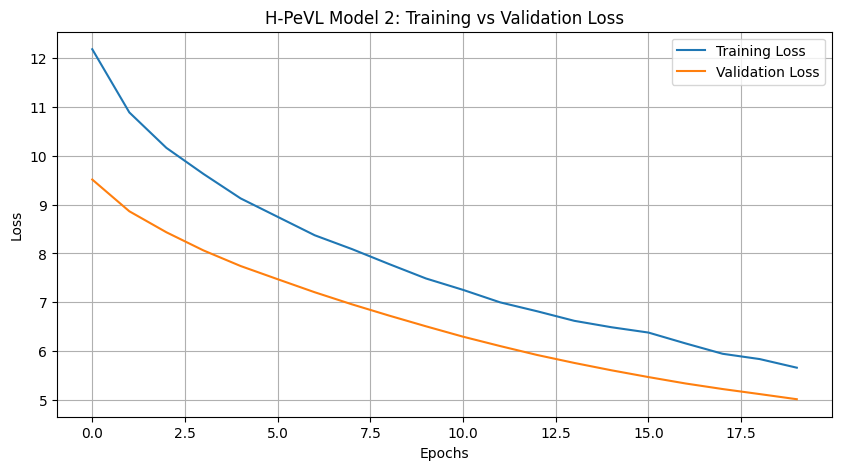

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


=== Final H-PeVL Results ===
Top-1 Accuracy: 47.23%
Top-5 Accuracy: 91.49%


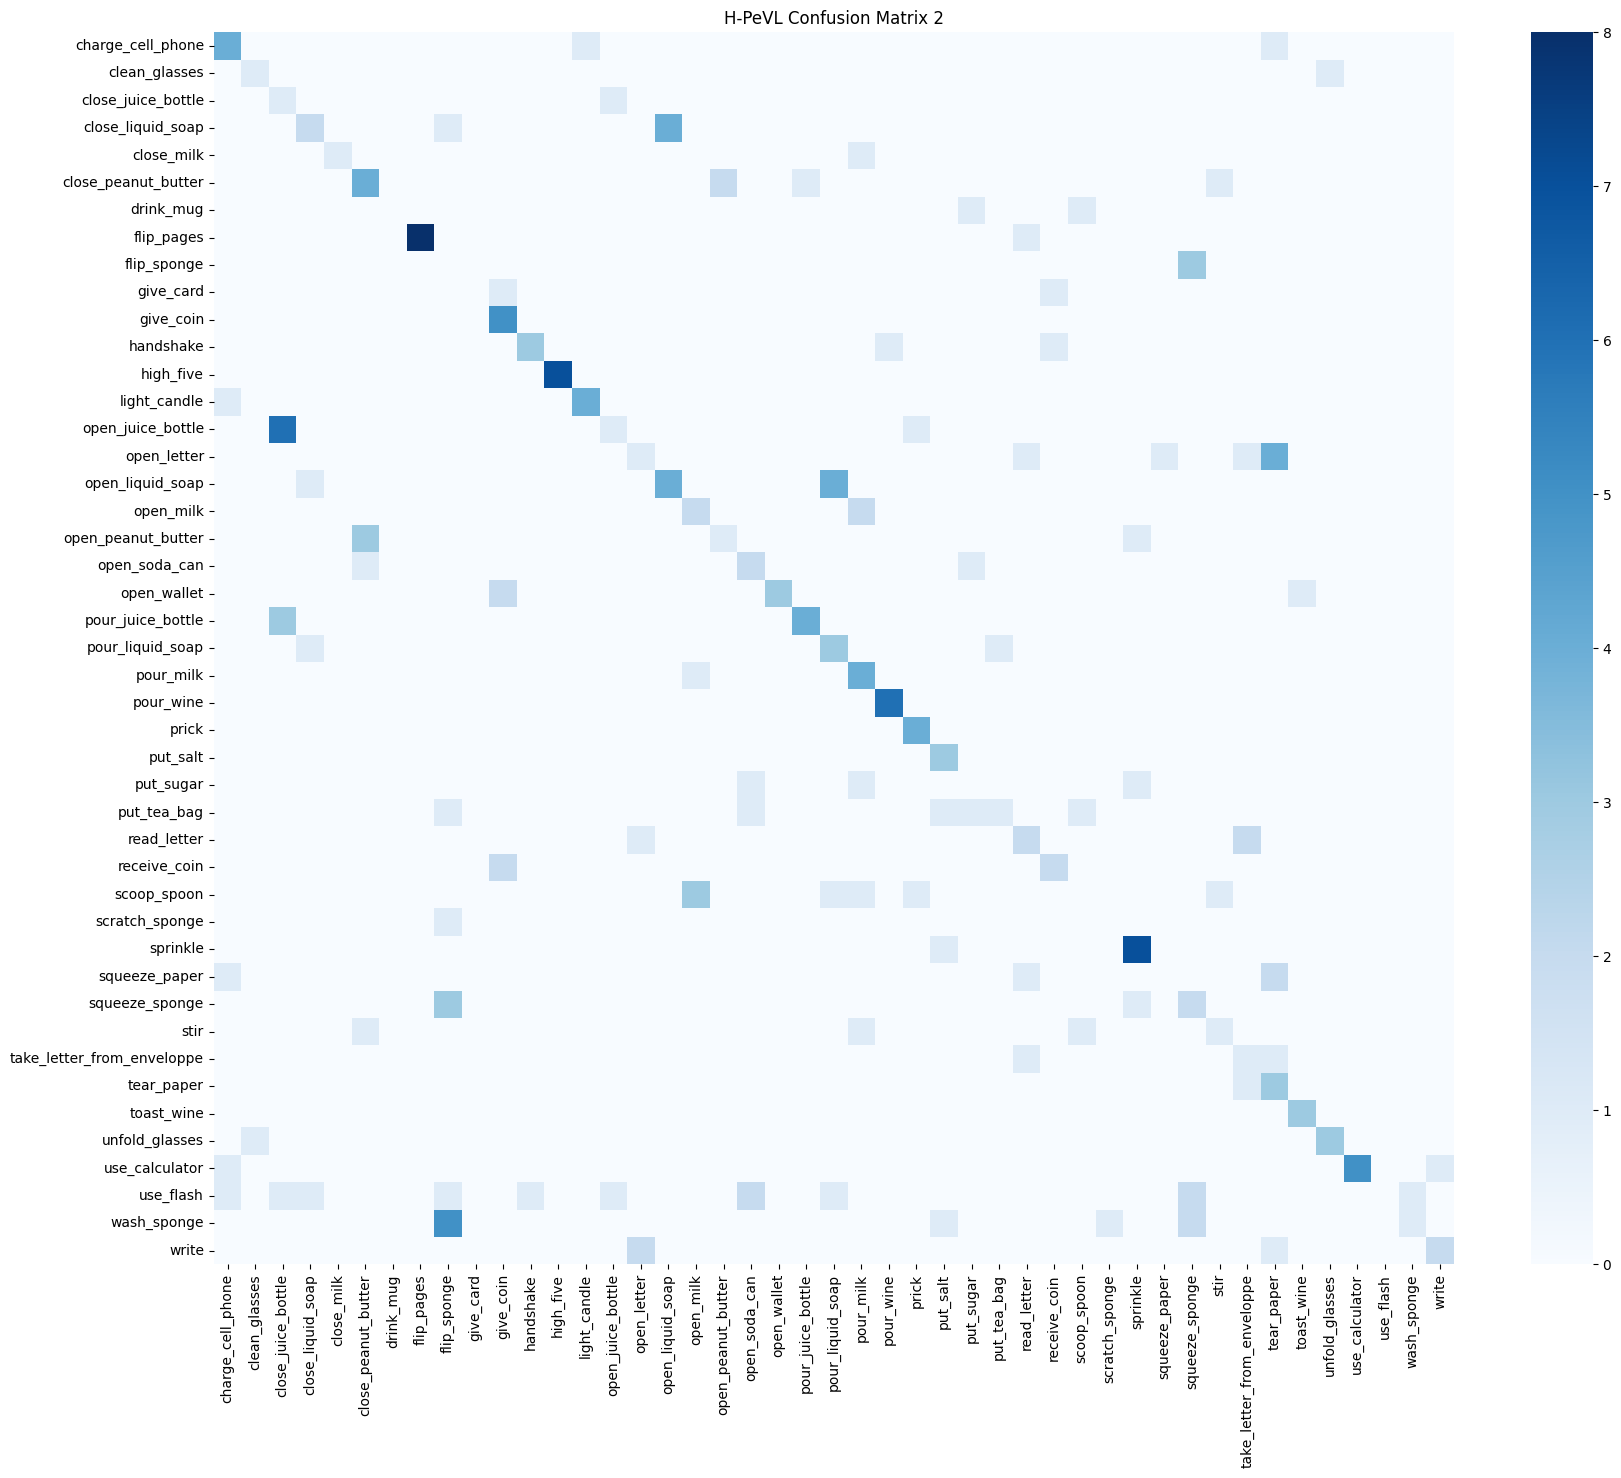

In [ ]:
# ==================================
# Cell 6: Final H-PeVL Evaluation & Visualization
# ==================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import json
import torch.nn.functional as F

# 1. Load the Best Model
print("Loading best H-PeVL model...")
model = HPeVLModel().to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 2. Plot Loss Curves
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('H-PeVL Model 2: Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 3. Setup Global Evaluation
all_actions = sorted(list(set([
    'charge_cell_phone', 'clean_glasses', 'close_juice_bottle', 'close_liquid_soap', 'close_milk',
    'close_peanut_butter', 'drink_mug', 'flip_pages', 'flip_sponge', 'give_card', 'give_coin',
    'handshake', 'high_five', 'light_candle', 'open_juice_bottle', 'open_letter', 'open_liquid_soap',
    'open_milk', 'open_peanut_butter', 'open_soda_can', 'open_wallet', 'pour_juice_bottle',
    'pour_liquid_soap', 'pour_milk', 'pour_wine', 'prick', 'put_salt', 'put_sugar', 'put_tea_bag',
    'read_letter', 'receive_coin', 'scoop_spoon', 'scratch_sponge', 'sprinkle', 'squeeze_paper',
    'squeeze_sponge', 'stir', 'take_letter_from_enveloppe', 'tear_paper', 'toast_wine', 'unfold_glasses',
    'use_calculator', 'use_flash', 'wash_sponge', 'write'
])))
action_to_idx = {action: i for i, action in enumerate(all_actions)}

# Pre-encode text
text_prompts = [f"a video of a hand performing the action of {action}" for action in all_actions]
text_inputs = processor(text=text_prompts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    class_embeddings = model.clip.get_text_features(**text_inputs)
    class_embeddings = model.text_adapter(class_embeddings)
    class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)

# 4. Inference Loop
all_logits = []
all_targets = []

eval_loader = val_loader

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        pose_values = batch["pose_values"].to(device) # <--- Pose Input
        batch_texts = batch["text"]

        # --- Manual Forward Pass for Inference ---
        # 1. Video Features
        b, n, c, h, w = pixel_values.shape
        pixel_values = pixel_values.view(b * n, c, h, w)
        frame_features = model.clip.get_image_features(pixel_values).view(b, n, -1)

        # 2. Pose Features
        pose_features = model.pose_encoder(pose_values)

        # 3. UCMR Refinement
        refined_video_seq, refined_pose_seq, _ = model.ucmr(frame_features, pose_features)

        # 4. Final Features (Mean + Adapter)
        video_emb = model.video_adapter(refined_video_seq.mean(dim=1))
        pose_emb = model.pose_adapter(refined_pose_seq.mean(dim=1))

        # 5. Fusion (Same as your SGMC Loss Logic)
        fused_emb = (F.normalize(video_emb, dim=-1) + F.normalize(pose_emb, dim=-1)) / 2.0
        fused_emb = F.normalize(fused_emb, dim=-1)

        # Calculate Logits
        logit_scale = model.clip.logit_scale.exp()
        logits = (logit_scale * fused_emb @ class_embeddings.T)

        all_logits.append(logits.cpu())

        # Determine Ground Truth
        batch_indices = []
        for t in batch_texts:
            for action in all_actions:
                if action in t:
                    batch_indices.append(action_to_idx[action])
                    break
        all_targets.append(torch.tensor(batch_indices))

all_logits = torch.cat(all_logits, dim=0)
all_targets = torch.cat(all_targets, dim=0)

# 5. Calculate Metrics
def accuracy(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res

acc1, acc5 = accuracy(all_logits, all_targets, topk=(1, 5))

print(f"\n=== Final H-PeVL Results ===")
print(f"Top-1 Accuracy: {acc1.item():.2f}%")
print(f"Top-5 Accuracy: {acc5.item():.2f}%")

# Confusion Matrix
_, top_preds = all_logits.topk(1, 1, True, True)
cm = confusion_matrix(all_targets.numpy(), top_preds.squeeze().numpy())
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=all_actions, yticklabels=all_actions)
plt.title('H-PeVL Confusion Matrix 2')
plt.show()